In [1]:
%load_ext autoreload
%autoreload 2

import sys
import pathlib

# Ensure the notebook can import the local src package from the project root.
project_root = pathlib.Path.cwd()
if not (project_root / 'src').exists():
    project_root = project_root.parent
sys.path.insert(0, str(project_root.resolve()))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sunpy.net import Fido, attrs as a
import astropy.units as u
from astropy.io import fits
import sunpy.map


from src.utilities import make_cube

# Explorative Analisis

In [2]:
print(a.jsoc.Series)

sunpy.net.jsoc.attrs.Series

The JSOC Series to Download.

           Attribute Name           ...
----------------------------------- ...
aia_flatfield                       ...
aia_lev1                            ...
aia_lev1_euv_12s                    ...
aia_lev1_uv_24s                     ...
aia_lev1_vis_1h                     ...
aia_master_pointing3h               ...
aia_response                        ...
aia_temperature_summary_300s        ...
hmi_b_135s                          ...
hmi_b_5760s                         ...
hmi_b_720s                          ...
hmi_b_720s_dcon                     ...
hmi_b_720s_dcons                    ...
hmi_b_720s_e15w1332_cea             ...
hmi_b_720s_e15w1332_cutout          ...
hmi_b_90s                           ...
hmi_b_synoptic                      ...
hmi_b_synoptic_small                ...
hmi_bharp_720s                      ...
hmi_bharp_720s_nrt                  ...
hmi_bmap_lowres_latlon_720s         ...
hmi_bptr_720s_mod    

## Download SDO Data — 2026-04-01

Downloads one snapshot per channel from the **Solar Dynamics Observatory (SDO)**:

| Channel | Instrument | Observable | Series |
|---|---|---|---|
| Continuum | HMI | Intensitygram | `hmi.Ic_45s` |
| Doppler | HMI | LOS velocity | `hmi.V_45s` |
| Magnetogram | HMI | LOS magnetic field | `hmi.M_45s` |
| AIA | AIA | EUV + UV images | 9 wavelength channels |

Data is fetched via **VSO** using `sunpy.net.Fido`. All images are full-disk (4096 × 4096 px).

In [3]:
# Single snapshot: noon UTC on 2026-04-01 (1-hour window guarantees exactly one frame per series)
t_start = '2026-04-01 12:00:00'
t_end   = '2026-04-01 12:10:00'
time_range = a.Time(t_start, t_end)

### HMI — Continuum, Doppler, Magnetogram

In [4]:
# HMI Continuum (intensitygram) — visible-light image of the photosphere
result_continuum = Fido.search(
    time_range,
    a.Instrument.hmi,
    a.Physobs.intensity,
)
print("=== Continuum ===")
print(result_continuum)

# HMI Dopplergram — line-of-sight velocity (photospheric convection & flows)
result_doppler = Fido.search(
    time_range,
    a.Instrument.hmi,
    a.Physobs.los_velocity,
)
print("\n=== Doppler ===")
print(result_doppler)

# HMI Magnetogram — line-of-sight magnetic field strength
result_magnetogram = Fido.search(
    time_range,
    a.Instrument.hmi,
    a.Physobs.los_magnetic_field,
)
print("\n=== Magnetogram ===")
print(result_magnetogram)

=== Continuum ===
Results from 1 Provider:

13 Results from the VSOClient:
Source: https://sdac.virtualsolar.org/cgi/search
Data retrieval status: http://docs.virtualsolar.org/wiki/VSOHealthReport

       Start Time               End Time        Source Instrument    Wavelength    Provider  Physobs  Wavetype Extent Width Extent Length Extent Type   Size  
                                                                      Angstrom                                                                         Mibyte 
----------------------- ----------------------- ------ ---------- ---------------- -------- --------- -------- ------------ ------------- ----------- --------
2026-04-01 12:00:30.000 2026-04-01 12:00:31.000    SDO        HMI 6173.0 .. 6174.0     JSOC intensity   NARROW         4096          4096    FULLDISK -0.00098
2026-04-01 12:01:15.000 2026-04-01 12:01:16.000    SDO        HMI 6173.0 .. 6174.0     JSOC intensity   NARROW         4096          4096    FULLDISK -0.00098
2026-04

### AIA — EUV and UV channels

AIA observes the Sun at 9 wavelength channels covering the chromosphere, transition region, and corona.

| Wavelength (Å) | Region | Cadence |
|---|---|---|
| 94 | Flaring corona (~6 MK) | 12 s |
| 131 | Flaring / hot loops (~10 MK) | 12 s |
| 171 | Quiet corona / upper TR (~0.6 MK) | 12 s |
| 193 | Corona / hot flare plasma (~1.2 MK) | 12 s |
| 211 | Active region corona (~2 MK) | 12 s |
| 304 | Chromosphere / TR (~0.05 MK) | 12 s |
| 335 | Active region corona (~2.5 MK) | 12 s |
| 1600 | Upper photosphere / TR | 24 s |
| 1700 | Temperature minimum / photosphere | 24 s |

In [5]:
#aia_wavelengths = [94, 131, 171, 193, 211, 304, 335, 1600, 1700]  # Angstrom
aia_wavelengths = [94]
results_aia = {}
for wl in aia_wavelengths:
    results_aia[wl] = Fido.search(
        time_range,
        a.Instrument.aia,
        a.Wavelength(wl * u.angstrom),
    )
    print(f"=== AIA {wl} Å ===")
    print(results_aia[wl])

=== AIA 94 Å ===
Results from 1 Provider:

50 Results from the VSOClient:
Source: https://sdac.virtualsolar.org/cgi/search
Data retrieval status: http://docs.virtualsolar.org/wiki/VSOHealthReport
Total estimated size: 3.389 Gbyte

       Start Time               End Time        Source Instrument  Wavelength  Provider  Physobs  Wavetype Extent Width Extent Length Extent Type   Size  
                                                                    Angstrom                                                                       Mibyte 
----------------------- ----------------------- ------ ---------- ------------ -------- --------- -------- ------------ ------------- ----------- --------
2026-04-01 12:00:11.000 2026-04-01 12:00:12.000    SDO        AIA 94.0 .. 94.0     JSOC intensity   NARROW         4096          4096    FULLDISK 64.64844
2026-04-01 12:00:23.000 2026-04-01 12:00:24.000    SDO        AIA 94.0 .. 94.0     JSOC intensity   NARROW         4096          4096    FULLDISK 64.

In [6]:
download_dir = pathlib.Path('../data/raw/2026-04-01')
download_dir.mkdir(parents=True, exist_ok=True)

# --- Uncomment to trigger the actual download (~134 MB) ---

if download_dir.exists():
    print(f"Directory {download_dir} already exists. Skipping download.")
else:
    files_continuum   = Fido.fetch(result_continuum,   path=download_dir)
    files_doppler     = Fido.fetch(result_doppler,     path=download_dir)
    files_magnetogram = Fido.fetch(result_magnetogram, path=download_dir)

# for now we won't download the AIA data
# files_aia = {}
# for wl, result in results_aia.items():
#     files_aia[wl] = Fido.fetch(result, path=download_dir)

print(f"Download directory: {download_dir.resolve()}")

Directory ../data/raw/2026-04-01 already exists. Skipping download.
Download directory: /home/thomas/Desktop/sun_spots_pulsation_review/data/raw/2026-04-01


In [7]:
make_cube(download_dir / 'hmi.ic_45s.2026.04.*.continuum.fits', download_dir / 'hmi_continuum_cube.fits', overwrite=False)

Omiting execution: file already created at ../data/raw/2026-04-01/hmi_continuum_cube.fits


In [8]:
make_cube(download_dir / 'hmi.m_45s.2026.04.*.magnetogram.fits', download_dir / 'hmi_magnetogram_cube.fits', overwrite=False)
make_cube(download_dir / 'hmi.v_45s.2026.04.*.Dopplergram.fits', download_dir / 'hmi_doppler_cube.fits', overwrite=False)

Omiting execution: file already created at ../data/raw/2026-04-01/hmi_magnetogram_cube.fits
Omiting execution: file already created at ../data/raw/2026-04-01/hmi_doppler_cube.fits


then run 
```bash
ds9 *cube* 
```
in orther to see the 3 cubes in total each cube has 12 frames that is about 9 minutes no pulsation is appernt, the easiest chanel to identufy sunspot is continios and also magnetogram, but the doplegram does't show relevant information maybe a nonlinar scale will work

as next step we recopilate the cordinates of each sunspot taking an area of each sunspot and enlogating it on the direction of movement in other to take into acount the rotacion of the sun, with this we eill be able to dowload at leat 1 horur of data from those especifir sunspots

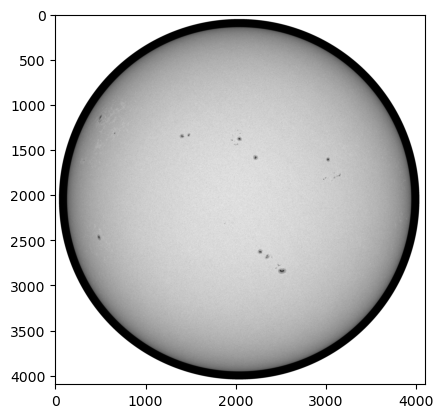

In [9]:
file_list = sorted(download_dir.glob('hmi.ic_45s.2026.04.*.continuum.fits'))


with fits.open(file_list[0]) as hdu:
    data_shape = hdu[1].data.shape
    header = hdu[1].header.copy()

plt.imshow(hdu[1].data, cmap='gray')
plt.show()

## Download especif data of each sunstop

box(2449.7054,2851.0634,231.25,90.972222,0)

bottom_left: Tx=-265.60 arcsec, Ty=-425.72 arcsec
top_right:   Tx=-148.98 arcsec,  Ty=-380.01 arcsec


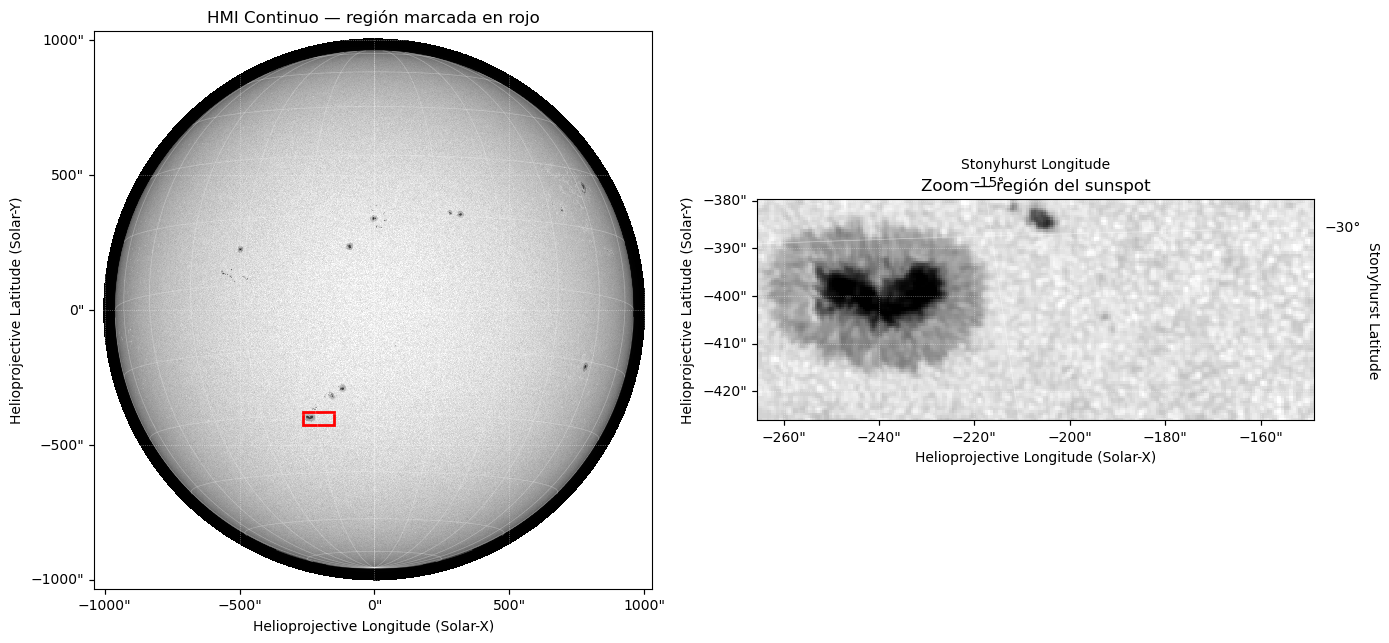

In [10]:
import sunpy.coordinates          # registra frames solares con astropy — no eliminar
import sunpy.map
from astropy.coordinates import SkyCoord
import astropy.units as u
import matplotlib.pyplot as plt

# Cargar primer frame de continuo completo (ya descargado)
fits_file = download_dir / 'hmi.ic_45s.2026.04.01_12_01_30_TAI.continuum.fits'

hmi_map = sunpy.map.Map(str(fits_file))

# ── Región en píxeles DS9 (1-indexado, imagen sin rotar)
x_c_ds9 = 2449.7054   # centro pixel x en DS9
y_c_ds9 = 2851.0634   # centro pixel y en DS9
w_px    = 231.25       # ancho en píxeles
h_px    = 90.972222    # alto en píxeles

# Con CROTA2≈180° en HMI: Tx ∝ −pixel_x, Ty ∝ −pixel_y
#   → bottom_left en HPC (min Tx, min Ty) = max pixel x, max pixel y
#   → top_right   en HPC (max Tx, max Ty) = min pixel x, min pixel y
# DS9 usa indexado desde 1; Astropy desde 0  →  restar 1
x_bl = x_c_ds9 + w_px / 2 - 1   # max pixel x → min Tx
y_bl = y_c_ds9 + h_px / 2 - 1   # max pixel y → min Ty
x_tr = x_c_ds9 - w_px / 2 - 1   # min pixel x → max Tx
y_tr = y_c_ds9 - h_px / 2 - 1   # min pixel y → max Ty

bottom_left = hmi_map.wcs.pixel_to_world(x_bl, y_bl)
top_right   = hmi_map.wcs.pixel_to_world(x_tr, y_tr)

print(f"bottom_left: Tx={bottom_left.Tx:.2f}, Ty={bottom_left.Ty:.2f}")
print(f"top_right:   Tx={top_right.Tx:.2f},  Ty={top_right.Ty:.2f}")

# HMI tiene CROTA2≈180° (norte abajo en el FITS crudo); rotate() corrige la orientación
hmi_map_rot = hmi_map.rotate(order=3)

# ── Figura: disco completo con recuadro rojo + zoom de la región
fig = plt.figure(figsize=(14, 7))

ax1 = fig.add_subplot(121, projection=hmi_map_rot)
hmi_map_rot.plot(axes=ax1, cmap='gray', clip_interval=(1, 99.9)*u.percent)
hmi_map_rot.draw_quadrangle(bottom_left, top_right=top_right,
                              edgecolor='red', linewidth=2)
hmi_map_rot.draw_grid(axes=ax1, color='white', alpha=0.3, lw=0.5)
ax1.set_title('HMI Continuo — región marcada en rojo')

region_map = hmi_map_rot.submap(bottom_left, top_right=top_right)
ax2 = fig.add_subplot(122, projection=region_map)
region_map.plot(axes=ax2, cmap='gray', clip_interval=(1, 99.9)*u.percent)
region_map.draw_grid(axes=ax2, color='white', alpha=0.5, lw=0.5)
ax2.set_title('Zoom — región del sunspot')

plt.tight_layout()
plt.show()


### Test — Same region on the magnetogram

`bottom_left` / `top_right` are `SkyCoord` objects in the **Helioprojective** frame tied to the continuum map's observer.  
When you pass them to a *different* map's `submap()` or `draw_quadrangle()`, sunpy automatically transforms them through `HeliographicStonyhurst` into the magnetogram's own frame — **no manual reprojection needed**.  
This works here because both `hmi.Ic_45s` and `hmi.m_45s` are taken by the same instrument (SDO/HMI) at essentially the same time (~30 s apart), so the observer position and WCS are virtually identical.

In [11]:
# ── Load HMI Magnetogram (hmi.m_45s) ──────────────────────────────────────────
# Same timestamp as the continuum frame loaded above.
# sunpy.map.Map reads compressed BINTABLE (HDU 1) automatically.
#
# Known WCS quirk: HMI magnetogram headers carry CRDER1/CRDER2 = nan and
# CSYSER1/CSYSER2 = nan.  sunpy ≥ 0.9 emits a SunpyMetadataWarning about
# these NaN values but loads and plots the map correctly — no fix needed for
# visualization.  The CUNIT='arcsec' + HPLN-TAN WCS is handled natively by
# sunpy, so submap() and draw_quadrangle() work without any manual correction.

import warnings
from sunpy.util import SunpyMetadataWarning

mag_fits_file = download_dir / 'hmi.m_45s.2026.04.01_12_01_30_TAI.magnetogram.fits'

with warnings.catch_warnings():
    # Suppress the expected NaN-in-CRDER/CSYSER metadata warning
    warnings.simplefilter('ignore', SunpyMetadataWarning)
    hmi_mag_map = sunpy.map.Map(str(mag_fits_file))

# Rotate to north-up (CROTA2 ≈ 179.9° in the raw FITS, same as continuum)
hmi_map_mag_rot = hmi_mag_map.rotate(order=3)

print(f"Magnetogram loaded  : {mag_fits_file.name}")
print(f"  Shape             : {hmi_mag_map.data.shape}")
print(f"  T_OBS             : {hmi_mag_map.meta.get('t_obs', 'N/A')}")
print(f"  BUNIT             : {hmi_mag_map.meta.get('bunit', 'N/A')}")
print(f"  Observer          : {hmi_mag_map.observer_coordinate}")


Magnetogram loaded  : hmi.m_45s.2026.04.01_12_01_30_TAI.magnetogram.fits
  Shape             : (4096, 4096)
  T_OBS             : 2026.04.01_12:01:30_TAI
  BUNIT             : Gauss
  Observer          : <SkyCoord (HeliographicStonyhurst: obstime=2026-04-01T12:01:30.000, rsun=696000.0 km): (lon, lat, radius) in (deg, deg, m)
    (0.01417496, -6.524251, 1.49492167e+11)>


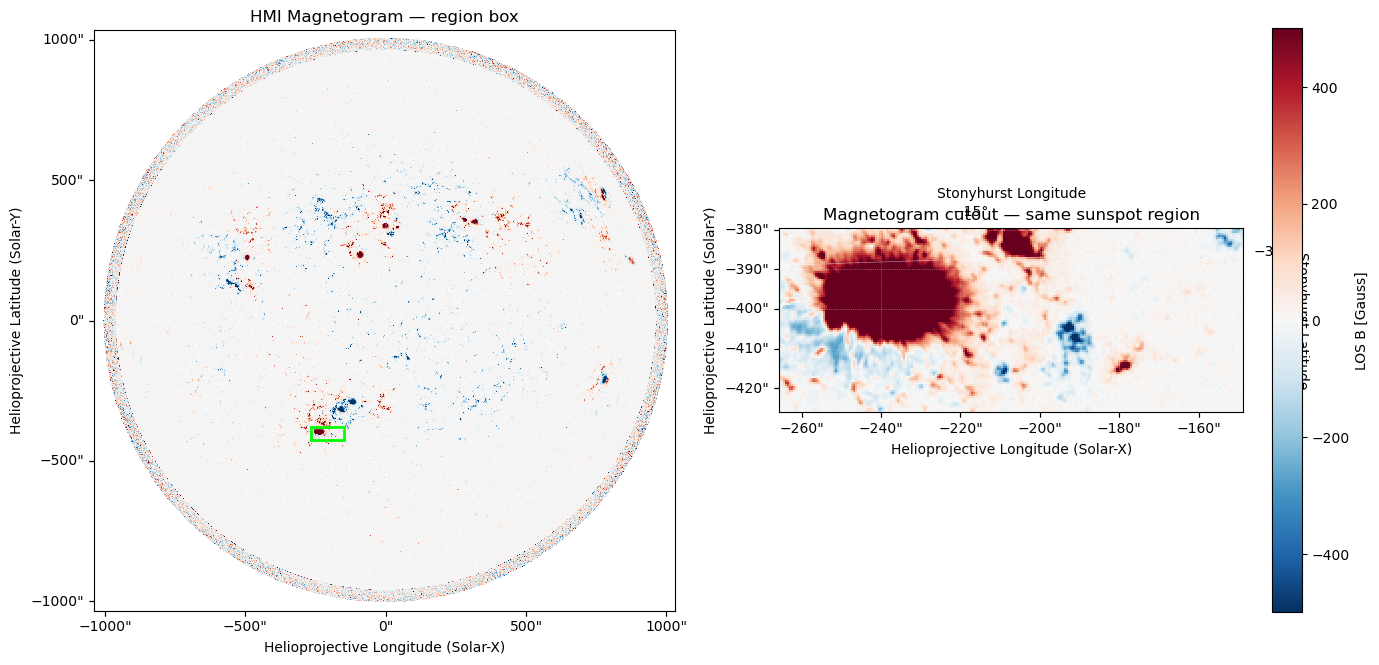

Continuum observer : <SkyCoord (HeliographicStonyhurst: obstime=2026-04-01T12:01:30.000, rsun=696000.0 km): (lon, lat, radius) in (deg, deg, m)
    (0.01417496, -6.524251, 1.49492167e+11)>
Magnetogram observer: <SkyCoord (HeliographicStonyhurst: obstime=2026-04-01T12:01:30.000, rsun=696000.0 km): (lon, lat, radius) in (deg, deg, m)
    (0.01417496, -6.524251, 1.49492167e+11)>


In [12]:
# hmi_map_mag_rot  → magnetogram, north-up (defined in the cell that loads hmi.m_45s)
# bottom_left, top_right → HPC SkyCoord computed from the continuum (cell above)
# sunpy transforms them into the magnetogram frame automatically via HeliographicStonyhurst

fig = plt.figure(figsize=(14, 7))

# -- Left: full-disk magnetogram with the region box --
ax1 = fig.add_subplot(121, projection=hmi_map_mag_rot)
hmi_map_mag_rot.plot(
    axes=ax1,
    cmap='RdBu_r',
    norm=plt.Normalize(vmin=-500, vmax=500),
)
hmi_map_mag_rot.draw_quadrangle(
    bottom_left, top_right=top_right,
    edgecolor='lime', linewidth=2,
)
hmi_map_mag_rot.draw_grid(axes=ax1, color='white', alpha=0.3, lw=0.5)
ax1.set_title('HMI Magnetogram — region box')

# -- Right: cutout of the same region --
mag_cutout = hmi_map_mag_rot.submap(bottom_left, top_right=top_right)
ax2 = fig.add_subplot(122, projection=mag_cutout)
mag_cutout.plot(
    axes=ax2,
    cmap='RdBu_r',
    norm=plt.Normalize(vmin=-500, vmax=500),
)
mag_cutout.draw_grid(axes=ax2, color='white', alpha=0.5, lw=0.5)
ax2.set_title('Magnetogram cutout — same sunspot region')

plt.colorbar(ax2.images[0], ax=ax2, label='LOS B [Gauss]')
plt.tight_layout()
plt.show()

print(f"Continuum observer : {hmi_map.observer_coordinate}")
print(f"Magnetogram observer: {hmi_mag_map.observer_coordinate}")


In [13]:
# tracking=True: el cutout sigue la rotación solar → la mancha queda centrada en toda la serie
# bottom_left y top_right definidos en la celda de visualización anterior
cutout = a.jsoc.Cutout(bottom_left, top_right=top_right, tracking=True)

# Búsqueda — un único frame para verificar
# Para 1 hora completa → a.Time('2026-04-01T12:00:00', '2026-04-01T13:00:00')
result_region = Fido.search(
    a.Time('2026-04-01T12:00:00', '2026-04-01T17:03:30'),
    a.jsoc.Series('hmi.Ic_45s'),
    a.jsoc.Notify('thomas.quamtum@gmail.com'),
    cutout,
)
print(result_region)


Results from 1 Provider:

405 Results from the JSOCClient:
Source: http://jsoc.stanford.edu

         T_REC          TELESCOP  INSTRUME  WAVELNTH CAR_ROT
----------------------- -------- ---------- -------- -------
2026.04.01_12:00:45_TAI  SDO/HMI HMI_FRONT2   6173.0    2309
2026.04.01_12:01:30_TAI  SDO/HMI HMI_FRONT2   6173.0    2309
2026.04.01_12:02:15_TAI  SDO/HMI HMI_FRONT2   6173.0    2309
2026.04.01_12:03:00_TAI  SDO/HMI HMI_FRONT2   6173.0    2309
2026.04.01_12:03:45_TAI  SDO/HMI HMI_FRONT2   6173.0    2309
2026.04.01_12:04:30_TAI  SDO/HMI HMI_FRONT2   6173.0    2309
2026.04.01_12:05:15_TAI  SDO/HMI HMI_FRONT2   6173.0    2309
2026.04.01_12:06:00_TAI  SDO/HMI HMI_FRONT2   6173.0    2309
2026.04.01_12:06:45_TAI  SDO/HMI HMI_FRONT2   6173.0    2309
2026.04.01_12:07:30_TAI  SDO/HMI HMI_FRONT2   6173.0    2309
2026.04.01_12:08:15_TAI  SDO/HMI HMI_FRONT2   6173.0    2309
2026.04.01_12:09:00_TAI  SDO/HMI HMI_FRONT2   6173.0    2309
2026.04.01_12:09:45_TAI  SDO/HMI HMI_FRONT2   6173.0 

In [14]:
# Download the single-region cutout using scripts.py:
# from src.scripts import download_single_region
# region_dir = pathlib.Path('../data/raw/sunspot_region')
# files_region = download_single_region(result_region, region_dir)


### All Sunspot Regions — Parse, Visualize and Download

7 valid regions found
Region 01: BL=(-299.4 arcsec, -424.2 arcsec)  TR=(-182.7 arcsec, -378.5 arcsec)
Region 02: BL=(-222.4 arcsec, -336.3 arcsec)  TR=(-80.6 arcsec, -276.9 arcsec)
Region 03: BL=(724.1 arcsec, -243.1 arcsec)  TR=(831.4 arcsec, -187.1 arcsec)
Region 04: BL=(-166.6 arcsec, 206.2 arcsec)  TR=(-30.2 arcsec, 259.9 arcsec)
Region 05: BL=(-78.1 arcsec, 293.1 arcsec)  TR=(74.2 arcsec, 376.0 arcsec)
Region 06: BL=(-549.6 arcsec, 195.3 arcsec)  TR=(-450.3 arcsec, 246.4 arcsec)
Region 07: BL=(216.4 arcsec, 331.7 arcsec)  TR=(379.6 arcsec, 380.8 arcsec)


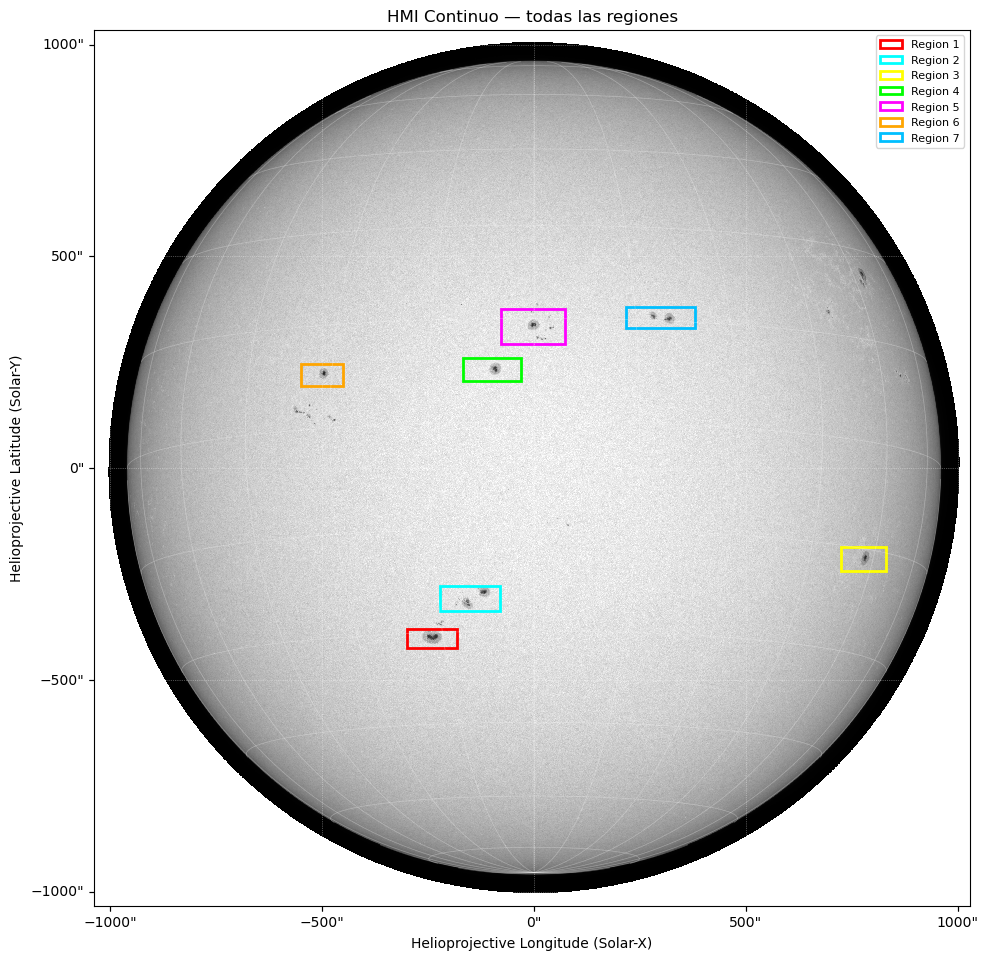

In [15]:
import re
from src.utilities import ds9_box_to_hpc, plot_regions_on_map

# hmi_map and hmi_map_rot are defined in the cell above (cell 8088e726)

# Parse ds9.txt — format: box(x_center, y_center, width, height, angle)
# Skip entries with zero size (unfinished regions)
ds9_file = pathlib.Path('../data/raw/ds9.txt')
regions_raw = []
for line in ds9_file.read_text().strip().splitlines():
    m = re.match(r'box\(([^)]+)\)', line)
    if m:
        x_c, y_c, w, h, _ = map(float, m.group(1).split(','))
        if w > 0 and h > 0:
            regions_raw.append((x_c, y_c, w, h))

print(f"{len(regions_raw)} valid regions found")

regions_hpc = [ds9_box_to_hpc(x, y, w, h, hmi_map) for x, y, w, h in regions_raw]
for i, (bl, tr) in enumerate(regions_hpc):
    print(f"Region {i+1:02d}: BL=({bl.Tx:.1f}, {bl.Ty:.1f})  TR=({tr.Tx:.1f}, {tr.Ty:.1f})")

plot_regions_on_map(hmi_map_rot, regions_hpc)

In [16]:
base_dir = pathlib.Path('../data/raw/regions')

for i, (bl, tr) in enumerate(regions_hpc):
    region_dir = base_dir / f'region_{i+1:02d}'
    region_dir.mkdir(parents=True, exist_ok=True)

    cutout = a.jsoc.Cutout(bl, top_right=tr, tracking=True)
    result = Fido.search(
        a.Time('2026-04-01T13:00:00', '2026-04-01T17:00:00'),
        a.jsoc.Series('hmi.Ic_45s'),
        a.jsoc.Notify('thomas.quamtum@gmail.com'),
        cutout,
    )
    print(f"Region {i+1:02d}: {len(result[0])} frames found")

# To download all regions, run:
# from src.scripts import download_regions_continuum
# download_regions_continuum(regions_hpc, base_dir, '2026-04-01T13:00:00', '2026-04-01T17:00:00', 'thomas.quamtum@gmail.com')


Region 01: 321 frames found
Region 02: 321 frames found
Region 03: 321 frames found
Region 04: 321 frames found
Region 05: 321 frames found
Region 06: 321 frames found
Region 07: 321 frames found


In [17]:
# Build FITS cubes for all continuum regions:
# from src.scripts import make_continuum_cubes
# make_continuum_cubes(regions_hpc, base_dir)


In [18]:
# Build FITS cubes for all magneto (Ic_45s) regions:
# from src.scripts import make_magneto_cubes
# make_magneto_cubes(regions_hpc, base_dir)


### All Sunspot Regions — Magnetogram (`hmi.M_45s`)

Same `regions_hpc` coordinates computed above from the continuum WCS — no re-parsing needed.

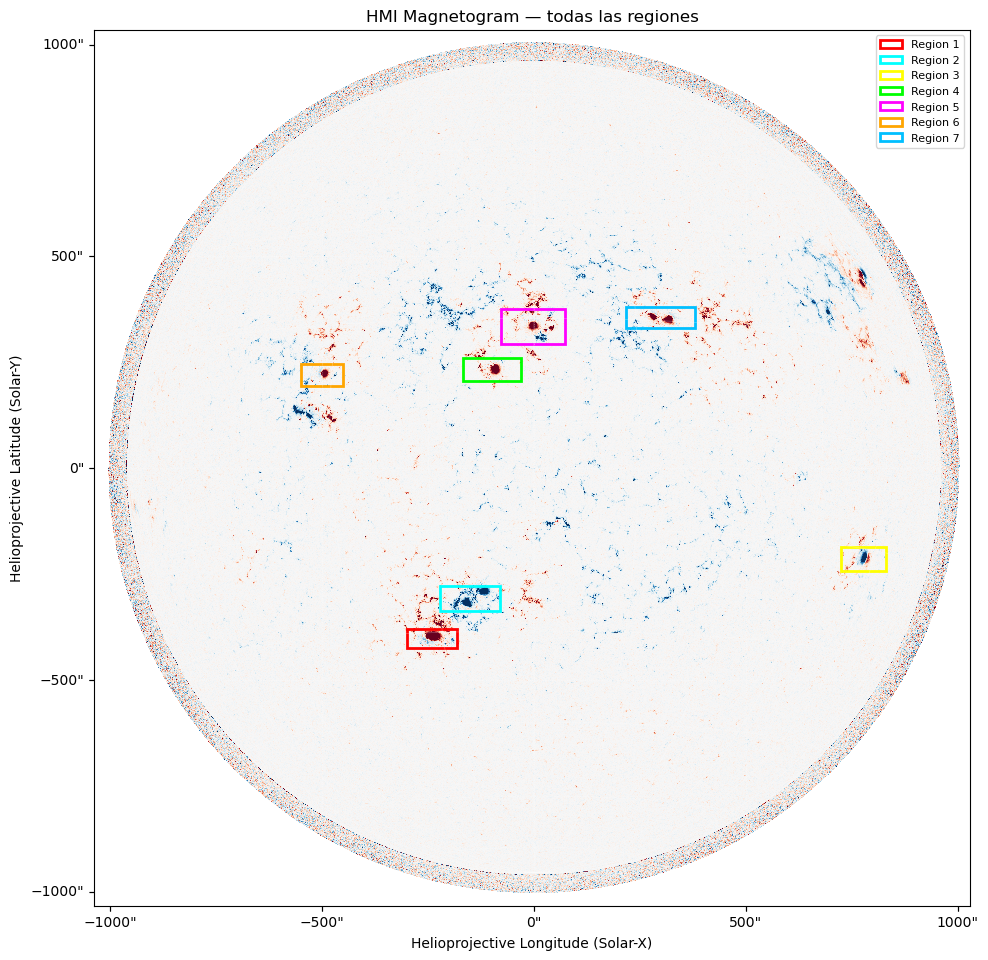

In [24]:
plot_regions_on_map(hmi_map_mag_rot, regions_hpc)    # magnetogram — auto-adapts


In [19]:
base_dir_mag = pathlib.Path('../data/raw/regions')

for i, (bl, tr) in enumerate(regions_hpc):
    region_dir = base_dir_mag / f'region_{i+1:02d}'
    region_dir.mkdir(parents=True, exist_ok=True)

    cutout = a.jsoc.Cutout(bl, top_right=tr, tracking=True)
    result = Fido.search(
        a.Time('2026-04-01T13:00:00', '2026-04-01T17:00:00'),
        a.jsoc.Series('hmi.M_45s'),
        a.jsoc.Notify('thomas.quamtum@gmail.com'),
        cutout,
    )
    print(f"Region {i+1:02d}: {len(result[0])} frames found")

# To download all magnetogram regions, run:
# from src.scripts import download_regions_magnetogram
# download_regions_magnetogram(regions_hpc, base_dir_mag, '2026-04-01T13:00:00', '2026-04-01T17:00:00', 'thomas.quamtum@gmail.com')


Region 01: 321 frames found
Region 02: 321 frames found
Region 03: 321 frames found
Region 04: 321 frames found
Region 05: 321 frames found
Region 06: 321 frames found
Region 07: 321 frames found


In [ ]:
# Build FITS cubes for all magnetogram regions:
# from src.scripts import make_magnetogram_cubes
# make_magnetogram_cubes(regions_hpc, base_dir_mag)
